# Clasificación — Regresión Logística

_Sigmoide, probabilidades, frontera de decisión y métricas_

**Módulo 1 — Aprendizaje Supervisado** | DSRP Machine Learning Engineering  
**Profesor:** Miguel Arquez

![Aprendizaje Supervisado](assets/header.png)

## 1. ¿Qué es la clasificación?

Predecir una etiqueta categórica:

- **Binaria**: $y \in \{0, 1\}$ — por ejemplo, _"¿el cliente se va o se queda?"_
- **Multiclase**: $y \in \{1, \dots, K\}$ — por ejemplo, tipo de producto.

Como la salida es discreta, no podemos usar regresión lineal directamente: nos interesa estimar una **probabilidad** entre 0 y 1.

## 2. La función sigmoide

Para que un modelo lineal entregue probabilidades válidas, pasamos su salida por la **sigmoide**, que aplasta cualquier número real al rango $(0, 1)$:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

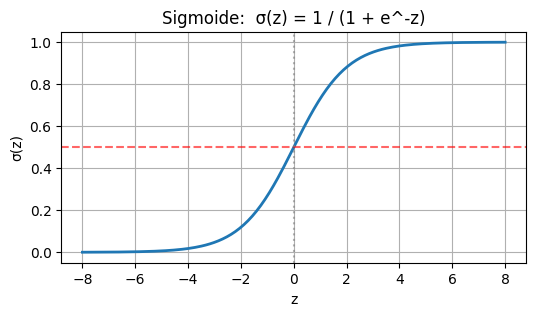

In [1]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-8, 8, 200)
plt.figure(figsize=(6, 3))
plt.plot(z, 1 / (1 + np.exp(-z)), lw=2)
plt.axhline(0.5, color='red', ls='--', alpha=0.6)
plt.axvline(0,   color='gray', ls=':',  alpha=0.6)
plt.title('Sigmoide:  σ(z) = 1 / (1 + e^-z)')
plt.xlabel('z'); plt.ylabel('σ(z)')
plt.grid(True); plt.show()

## 3. El modelo de regresión logística

Aplicamos la sigmoide a una combinación lineal de los predictores:

$$
P(y = 1 \mid x) = \sigma\!\left(\beta_0 + \beta_1 x_1 + \dots + \beta_p x_p\right)
$$

Es una **regresión lineal con un "sombrero" sigmoide** que la convierte en probabilidad. El modelo se ajusta buscando los $\beta$ que hagan que las probabilidades predichas se parezcan lo más posible a las etiquetas reales (internamente minimiza la **log-loss**; para nosotros lo importante es que `scikit-learn` lo hace en una línea).

## 4. Frontera de decisión

Con un umbral típico de 0.5, clasificamos como positivo si $\hat{p} \ge 0.5$. En el espacio de los predictores eso es una **línea recta** (o hiperplano): por eso la regresión logística genera **fronteras lineales**.

El umbral se puede mover según el costo de los errores: bajarlo aumenta el recall (no perder positivos), subirlo aumenta la precisión.

## 5. Métricas de clasificación

**Matriz de confusión**:

|              | Pred. positivo | Pred. negativo |
|---|---|---|
| **Real positivo** | TP | FN |
| **Real negativo** | FP | TN |

$$
\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN}
\qquad
\text{Precision} = \frac{TP}{TP+FP}
\qquad
\text{Recall} = \frac{TP}{TP+FN}
$$

$$
F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

- **Accuracy** — qué fracción acertamos. Engaña con clases desbalanceadas.
- **Precision** — de los que dije positivos, ¿cuántos lo eran?
- **Recall** — de los positivos reales, ¿cuántos detecté?
- **F1** — promedio armónico de precision y recall.
- **ROC-AUC** — área bajo la curva TPR vs FPR al variar el umbral. AUC = 1 perfecto, AUC = 0.5 aleatorio.

## 6. Caso práctico — Telco Customer Churn (Kaggle)

**Dataset:** https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
**Archivo:** `WA_Fn-UseC_-Telco-Customer-Churn.csv` (7.043 × 21).

**Estructura.** Cada fila es un cliente. Las 21 columnas se agrupan así:

- **Identificador**: `customerID`.
- **Demografía**: `gender`, `SeniorCitizen` (0/1), `Partner`, `Dependents`.
- **Cuenta**: `tenure` (meses con la compañía), `Contract` (Month-to-month / One year / Two year), `PaperlessBilling`, `PaymentMethod`.
- **Servicios**: `PhoneService`, `MultipleLines`, `InternetService` (DSL / Fiber / No), `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`.
- **Facturación**: `MonthlyCharges` (USD/mes), `TotalCharges` (USD acumulado — viene como string con espacios para clientes nuevos, hay que convertir a numérico).
- **Target**: `Churn` (Yes / No).

**Problema:** clasificación binaria — predecir si el cliente se va a dar de baja. Hay desbalance moderado (≈26.5% churners). El loader ya:
1. convierte `TotalCharges` a numérico y descarta las filas con NaN,
2. mapea `Churn` a 1/0.

In [2]:
from pathlib import Path
import pandas as pd

DATA = Path('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
if not DATA.exists():
    raise FileNotFoundError(
        f'No se encontró {DATA}. Descarga el dataset desde '
        'https://www.kaggle.com/datasets/blastchar/telco-customer-churn '
        'y colócalo en data/ (ver README.md).'
    )

df = pd.read_csv(DATA)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
print('Shape:', df.shape, '| Tasa de churn:', round(df.Churn.mean(), 3))
df.head()

Shape: (7032, 21) | Tasa de churn: 0.266


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [3]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay,
)

sns.set_theme(style='whitegrid')

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
            'InternetService', 'Contract', 'PaperlessBilling', 'PaymentMethod']

X = pd.get_dummies(df[num_cols + cat_cols], columns=cat_cols, drop_first=True)
y = df['Churn']
print('Shape de X:', X.shape)

Shape de X: (7032, 16)


In [4]:
X

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,0,False,True,False,False,False,False,False,False,True,False,True,False
1,34,56.95,1889.50,0,True,False,False,True,False,False,True,False,False,False,False,True
2,2,53.85,108.15,0,True,False,False,True,False,False,False,False,True,False,False,True
3,45,42.30,1840.75,0,True,False,False,False,False,False,True,False,False,False,False,False
4,2,70.70,151.65,0,False,False,False,True,True,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,24,84.80,1990.50,0,True,True,True,True,False,False,True,False,True,False,False,True
7028,72,103.20,7362.90,0,False,True,True,True,True,False,True,False,True,True,False,False
7029,11,29.60,346.45,0,False,True,True,False,False,False,False,False,True,False,True,False
7030,4,74.40,306.60,1,True,True,False,True,True,False,False,False,True,False,False,True


In [5]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

logit = LogisticRegression(max_iter=1000).fit(X_tr_s, y_tr)

coefs = pd.DataFrame({
    'feature': X.columns,
    'beta': logit.coef_[0],
}).sort_values('beta', key=abs, ascending=False).head(12)
coefs

,feature,beta
0,tenure,-1.342939
11,Contract_Two year,-0.685092
2,TotalCharges,0.613475
8,InternetService_Fiber optic,0.417587
10,Contract_One year,-0.345990
7,PhoneService_Yes,-0.221547
14,PaymentMethod_Electronic check,0.213153
12,PaperlessBilling_Yes,0.169158
1,MonthlyCharges,0.167421
9,InternetService_No,-0.151308


**Cómo leer los coeficientes (intuición sin entrar en log-odds):**
- `beta` positivo → la variable **empuja la probabilidad de churn hacia arriba**.
- `beta` negativo → empuja la probabilidad **hacia abajo**.
- Magnitud → cuánto. Como estandarizamos los predictores, las magnitudes son comparables entre sí.

In [8]:
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(1407,))

In [16]:
np.array([int(i) for i in y_proba > 0.1])

array([0, 1, 0, ..., 1, 0, 0], shape=(1407,))

In [7]:
y_pred = logit.predict(X_te_s)
y_proba = logit.predict_proba(X_te_s)[:, 1]

print(f'Accuracy  : {accuracy_score(y_te, y_pred):.3f}')
print(f'Precision : {precision_score(y_te, y_pred):.3f}')
print(f'Recall    : {recall_score(y_te, y_pred):.3f}')
print(f'F1        : {f1_score(y_te, y_pred):.3f}')
print(f'ROC AUC   : {roc_auc_score(y_te, y_proba):.3f}')

print('\n', classification_report(y_te, y_pred, target_names=['No churn', 'Churn']))

Accuracy  : 0.803
Precision : 0.650
Recall    : 0.561
F1        : 0.603
ROC AUC   : 0.835

               precision    recall  f1-score   support

    No churn       0.85      0.89      0.87      1033
       Churn       0.65      0.56      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



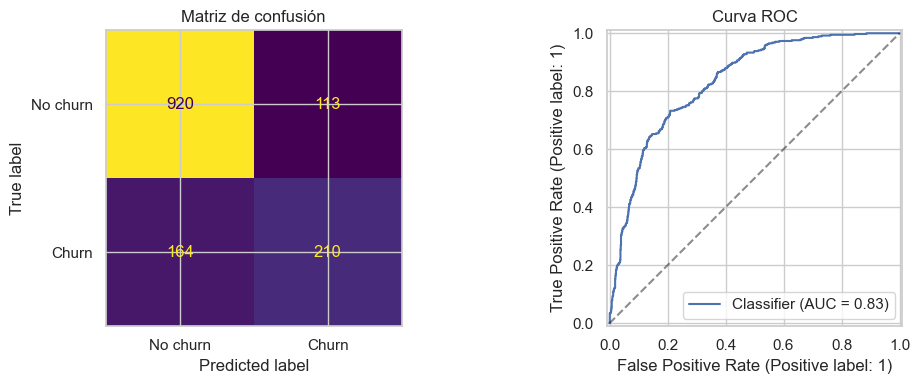

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_te, y_pred),
    display_labels=['No churn', 'Churn'],
).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de confusión')

RocCurveDisplay.from_predictions(y_te, y_proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title('Curva ROC')
plt.tight_layout(); plt.show()

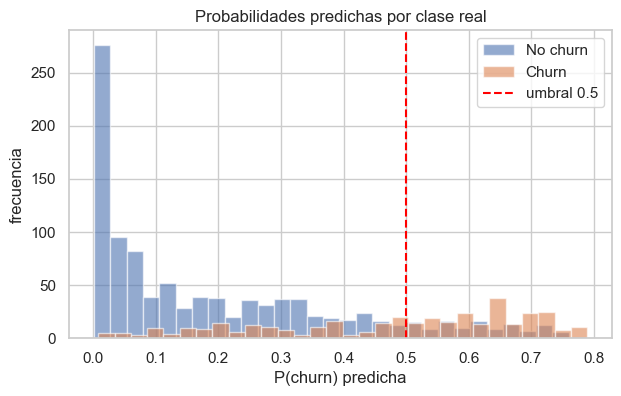

In [17]:
# --- Distribución de probabilidades por clase real ---
fig, ax = plt.subplots(figsize=(7, 4))
for label, name in [(0, 'No churn'), (1, 'Churn')]:
    ax.hist(y_proba[y_te == label], bins=30, alpha=0.6, label=name)
ax.axvline(0.5, color='red', ls='--', label='umbral 0.5')
ax.set_xlabel('P(churn) predicha'); ax.set_ylabel('frecuencia')
ax.set_title('Probabilidades predichas por clase real')
ax.legend(); plt.show()

## 7. Referencias

- ISLR cap. 4: *Classification*.
- Hosmer, Lemeshow & Sturdivant (2013). *Applied Logistic Regression*.
- scikit-learn user guide: https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
- Dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

## Predicción sobre datos nuevos — uso del modelo en producción

Una vez que el modelo está validado en el conjunto de test, queremos usarlo para predecir sobre datos que **no hemos visto**. En la práctica seguimos tres pasos:

1. **Reentrenar con todos los datos disponibles.** Ya hicimos la validación con la partición train/test; ahora aprovechamos el 100% de la información para que el modelo final tenga la mejor estimación posible de los parámetros.
2. **Aplicar exactamente las mismas transformaciones** que durante el entrenamiento (mismas columnas, mismo encoding, misma escala) — un error muy común en producción es desalinear el preprocesamiento.
3. **Persistir el modelo** con `joblib` (o `pickle`) para reutilizarlo sin reentrenar.

In [18]:
import joblib

# Reentrenamos sobre TODOS los datos
scaler_final = StandardScaler().fit(X)
modelo_final = LogisticRegression(max_iter=1000).fit(scaler_final.transform(X), y)

# Guardamos modelo + scaler + columnas en un solo bundle (para reproducir el # preprocesamiento en producción)
bundle = {
    'modelo':    modelo_final,
    'scaler':    scaler_final,
    'columnas':  X.columns.tolist(),
    'num_cols':  num_cols,
    'cat_cols':  cat_cols,
}
joblib.dump(bundle, 'modelo_telco_logit.pkl')
print('Bundle guardado.')

Bundle guardado.


### Inferencia individual — un cliente nuevo

**Detalle clave de producción.** Cuando aplicamos `pd.get_dummies` a un cliente individual, las columnas resultantes pueden ser distintas a las del entrenamiento (p. ej. si `Contract='Two year'` solo apareció en el train). El truco es **reindexar** contra `X.columns`: las columnas faltantes se rellenan con 0, las que sobran se descartan.

In [19]:
nuevo_cliente_raw = pd.DataFrame([{
    'tenure':            5,
    'MonthlyCharges':    85.0,
    'TotalCharges':      425.0,
    'SeniorCitizen':     0,
    'gender':            'Female',
    'Partner':           'No',
    'Dependents':        'No',
    'PhoneService':      'Yes',
    'InternetService':   'Fiber optic',
    'Contract':          'Month-to-month',
    'PaperlessBilling':  'Yes',
    'PaymentMethod':     'Electronic check',
}])

# Mismo encoding que en entrenamiento + alineación de columnas
nuevo = pd.get_dummies(nuevo_cliente_raw, columns=cat_cols, drop_first=True)
nuevo = nuevo.reindex(columns=X.columns, fill_value=0)

prob = modelo_final.predict_proba(scaler_final.transform(nuevo))[0, 1]
print(f'P(churn) = {prob:.3f}')
print(f'Predicción @ umbral 0.5: {"Churn" if prob >= 0.5 else "No churn"}')
print(f'Predicción @ umbral 0.3: {"Churn" if prob >= 0.3 else "No churn"}  '
      f'(más conservador, mayor recall)')

P(churn) = 0.499
Predicción @ umbral 0.5: No churn
Predicción @ umbral 0.3: Churn  (más conservador, mayor recall)


### Caso de uso: ranking de clientes por riesgo

En la realidad rara vez interesa la clasificación binaria pura. Lo más útil es **ordenar a los clientes por probabilidad de churn** y atacar a los del top con una campaña de retención (descuentos, llamadas, etc.). Por presupuesto, el equipo de retención solo puede llegar a, digamos, los 10 más riesgosos por semana.

In [20]:
test_proba = modelo_final.predict_proba(scaler_final.transform(X_te))[:, 1]
ranking = (
    pd.DataFrame({
        'P_churn':     test_proba.round(3),
        'churn_real':  y_te.values,
    })
    .sort_values('P_churn', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
print('Top 10 clientes con mayor probabilidad de churn (test set):')
ranking

Top 10 clientes con mayor probabilidad de churn (test set):


,P_churn,churn_real
0,0.792,1
1,0.786,1
2,0.784,0
3,0.777,1
4,0.774,1
5,0.772,1
6,0.772,1
7,0.770,1
8,0.769,1
9,0.768,1


**Lecciones para producción:**
- Guardar el `scaler` junto al modelo: predecir sin estandarizar **rompe** la regresión logística.
- El umbral 0.5 es un default, no una verdad: súbelo si los falsos positivos son caros (campañas), bájalo si los falsos negativos son caros (perder al cliente).
- Monitorear la **calibración** de las probabilidades en el tiempo (¿siguen reflejando frecuencias reales?).